### Implement few-shot prompting with GPT-2 for the classification task 

Article: The stock market is experiencing a significant downturn.
Category: Business

Article: Thousands braved heavy snow in Seoul to rally for and against arresting the President.
Category: World

Article: The Massachusetts Legislature approved a bill aimed at closing loopholes in the state’s health care market.
Category: Science/Technology

In [111]:
from transformers import GPT2Tokenizer

# Load GPT-2 tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("datasets/gpt2")

# List of categorical words
categories = ["World", "Sports", "Business", "Science/Technology"]

# Function to get the token length of a word
def get_token_length(word):
    tokens = tokenizer.tokenize(word)
    return len(tokens)

# Print the token lengths of the categorical words
for category in categories:
    length = get_token_length(category)
    print(f"The token length of '{category}' is {length}")

The token length of 'World' is 1
The token length of 'Sports' is 1
The token length of 'Business' is 1
The token length of 'Science/Technology' is 3


#### Test with few examples

In [68]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

# Load GPT-2 model and tokenizer
model_name = "datasets/gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()  # Set the model to evaluation mode

# Few-shot prompt examples for news classification
few_shot_prompt = """
Classify the category of the following news articles:
Options: World, Sports, Business, Science/Technology

Article: The stock market is facing challenges due to economic uncertainty.
Category: Business

Article: Protesters gathered in Seoul amid heavy snowfall to demand political reforms.
Category: World

Article: Taiwan's Foxconn, a leading electronics manufacturer, reported record revenue due to AI demand.
Category: Science/Technology

Article: The local football team celebrated their first championship win in over ten years.
Category: Sports

Article: [Test article here]
Category:
"""


# Define a function to get GPT-2 prediction for a new article
def get_gpt2_prediction(article):
    # Create the prompt with the test article
    prompt = few_shot_prompt.replace("[Test article here]", article)
    
    # Tokenize input
    inputs = tokenizer.encode(prompt, return_tensors='pt')

    # Generate prediction
    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_length=inputs.shape[1] + 100,
            do_sample=True,  # Enable sampling
            top_k=30,  # Use top-k sampling
            top_p=0.85,  # Use top-p (nucleus) sampling
            temperature=0.1,  # Adjust temperature for more creativity
            early_stopping=True,
            output_attentions=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
        
    # Decode and post-process the output
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Remove the prompt from the generated text
    generated_text = generated_text[len(prompt):].strip()
    
    return generated_text

# Example usage
test_article = "Rwanda Troops Start AU Mission in Darfur EL FASHER, Sudan (Reuters) - Rwandan troops arrived in Darfur Sunday as the first foreign force there, mandated to protect observers monitoring a shaky cease-fire between the Sudanese government and rebels in the remote western region."
prediction = get_gpt2_prediction(test_article)
print(f"Article: {test_article}\nPredicted category: {prediction}")

/home/pkd916/miniconda3/envs/assignment3/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
/home/pkd916/miniconda3/envs/assignment3/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


Article: Rwanda Troops Start AU Mission in Darfur EL FASHER, Sudan (Reuters) - Rwandan troops arrived in Darfur Sunday as the first foreign force there, mandated to protect observers monitoring a shaky cease-fire between the Sudanese government and rebels in the remote western region.
Predicted category: Article: The UN Security Council approved a resolution calling for the end of the violence in Darfur, which has killed more than 1,000 people since the start of the year.

Category: Science/Technology

Article: The UN Security Council approved a resolution calling for the end of the violence in Darfur, which has killed more than 1,000 people since the start of the year.

Category: Science/Technology

Article: The UN Security Council approved a resolution


#### Using GPT-2 prompt model to evaluation on test set 
#### Use GPT-2 to generate predictions for the test set based on the prompt.

In [64]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
import torchmetrics
from datasets import load_dataset

# Load the GPT-2 model and tokenizer
model_name = "datasets/gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()  # Set the model to evaluation mode

# Prepare the few-shot prompt with examples
few_shot_prompt = """
Classify the category of the following news articles:
Options: World, Sports, Business, Science/Technology

Article: The stock market is facing challenges due to economic uncertainty.
Category: Business

Article: Protesters gathered in Seoul amid heavy snowfall to demand political reforms.
Category: World

Article: Taiwan's Foxconn, a leading electronics manufacturer, reported record revenue due to AI demand.
Category: Science/Technology

Article: The local football team celebrated their first championship win in over ten years.
Category: Sports

Article: [Test article here]
Category:
"""

# Define a function to get GPT-2 prediction for a new sentence
def get_gpt2_prediction(sentence):
    # Create the prompt with the test article
    prompt = few_shot_prompt.replace("[Test article here]", sentence)
    
    # Tokenize input
    inputs = tokenizer.encode(prompt, return_tensors='pt').to(device)
    
    # Generate prediction
    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_length=inputs.shape[1] + 10,
            do_sample=False,
            num_beams=7,
            early_stopping=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
        
    # Decode and post-process the output
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Remove the prompt from the generated text
    generated_text = generated_text[len(prompt):].strip()
    
    # Map generated output to clean labels
    if "World" in generated_text:
        return "World"
    elif "Sports" in generated_text:
        return "Sports"
    elif "Business" in generated_text:
        return "Business"
    elif "Science" in generated_text or "Technology" in generated_text:
        return "Science/Technology"
    else:
        return "Unknown"

# Load the AG News dataset
dataset = load_dataset('datasets/ag_news', split='test')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Get the true labels and predictions
true_labels = []
predictions = []

for example in dataset:
    true_labels.append(example['label'])  # AG News labels: 0 - World, 1 - Sports, 2 - Business, 3 - Sci/Tech
    prediction = get_gpt2_prediction(example['text'])
    predictions.append(prediction)

# Convert predictions to numerical labels
label_mapping = {"World": 0, "Sports": 1, "Business": 2, "Science/Technology": 3}
pred_labels = torch.tensor([label_mapping.get(pred, -1) for pred in predictions]).to(device)
true_labels = torch.tensor(true_labels).to(device)

# Filter out unknown predictions
valid_indices = pred_labels != -1
pred_labels = pred_labels[valid_indices]
true_labels = true_labels[valid_indices]

# Initialize metrics
accuracy_metric = torchmetrics.Accuracy(task='multiclass', num_classes=4).to(device)
precision_metric = torchmetrics.Precision(task='multiclass', average='weighted', num_classes=4).to(device)
recall_metric = torchmetrics.Recall(task='multiclass', average='weighted', num_classes=4).to(device)
f1_metric = torchmetrics.F1Score(task='multiclass', average='weighted', num_classes=4).to(device)

# Update metrics with predictions
accuracy_metric.update(pred_labels, true_labels)
precision_metric.update(pred_labels, true_labels)
recall_metric.update(pred_labels, true_labels)
f1_metric.update(pred_labels, true_labels)

# Compute the metrics
accuracy = accuracy_metric.compute().item()
precision = precision_metric.compute().item()
recall = recall_metric.compute().item()
f1 = f1_metric.compute().item()

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.2857
Precision: 0.4708
Recall: 0.2857
F1 Score: 0.1797


#### f1 paramter of the model
Accuracy: 0.3520
Precision: 0.5552
Recall: 0.3520
F1 Score: 0.3031
#### This training setting ---- most label with 3 (Science and technology)
model.generate(
            inputs,
            max_length=inputs.shape[1] + 10,
            do_sample=False,
            num_beams=5,
            early_stopping=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id

#### Num_bean = 3 to test the model
Accuracy: 0.4364
Precision: 0.6034
Recall: 0.4364
F1 Score: 0.4001

#### Compare the classification accuracy between the GPT-2 few-shot prompting approach, the pre-trained (not fine-tuned) BERT model, and the fine-tuned BERT model. Report the accuracy, precision, recall, and F1-score for both models. Which model performs better? Discuss scenarios where one approach may outperform the other.

#### Discuss the trade-offs between fine-tuning and few-shot prompting in terms of computational resources, ease of implementation, and performance. Given GPT-2’s generative nature, what are the potential limitations when applyingit to classification tasks? Which approach would you recommend for a low-resource language? Why?

In [151]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

#### Provide and compare the attention map visualizations for the same example sentences as above (note that GPT-2’s attention mechanisms might differ).See Hints below. How do attention patterns differ between BERT and GPT-2?

In [59]:
attentions[9]

(tensor([[[[1.0750e-02, 1.2505e-02, 8.8083e-04,  ..., 2.3487e-02,
            2.3859e-02, 1.7188e-02]],
 
          [[5.5290e-06, 6.3718e-06, 1.4535e-05,  ..., 2.7165e-06,
            2.7399e-06, 4.7140e-01]],
 
          [[1.1446e-02, 3.2072e-03, 3.3268e-03,  ..., 1.2697e-02,
            1.3216e-02, 3.4044e-02]],
 
          ...,
 
          [[8.5879e-03, 7.3838e-03, 2.6905e-03,  ..., 3.1095e-02,
            3.2407e-02, 8.3761e-03]],
 
          [[5.9650e-03, 2.7422e-03, 3.7955e-03,  ..., 2.0454e-02,
            2.1207e-02, 1.6052e-01]],
 
          [[2.7965e-02, 8.0882e-03, 3.4026e-03,  ..., 6.5572e-03,
            6.5447e-03, 7.8077e-03]]]]),
 tensor([[[[4.8249e-03, 2.2948e-03, 2.0582e-03,  ..., 7.7135e-02,
            9.4716e-02, 1.4547e-01]],
 
          [[3.5618e-03, 7.9379e-05, 1.0472e-04,  ..., 2.2268e-01,
            2.7080e-01, 6.2475e-02]],
 
          [[9.5822e-04, 6.5160e-04, 6.7848e-04,  ..., 3.3675e-02,
            3.4274e-02, 2.9338e-02]],
 
          ...,
 
          [

In [91]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load GPT-2 model and tokenizer
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()  # Set the model to evaluation mode

# Few-shot prompt examples for news classification
few_shot_prompt = """
Classify the category of the following news articles:
Options: World, Sports, Business, Science/Technology

Article: The stock market is facing challenges due to economic uncertainty.
Category: Business

Article: Protesters gathered in Seoul amid heavy snowfall to demand political reforms.
Category: World

Article: Taiwan's Foxconn, a leading electronics manufacturer, reported record revenue due to AI demand.
Category: Science/Technology

Article: The local football team celebrated their first championship win in over ten years.
Category: Sports

Article: [Test article here]
Category:
"""

# Define a function to get GPT-2 prediction for a new article
def get_gpt2_prediction(article):
    # Create the prompt with the test article
    prompt = few_shot_prompt.replace("[Test article here]", article)
    
    # Tokenize input
    inputs = tokenizer.encode(prompt, return_tensors='pt')

    # Generate prediction
    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_length=inputs.shape[1] + 10,
            do_sample=False,  # Disable sampling
            return_dict_in_generate=True,  # Return additional information
            # output_hidden_states=True,  # Return hidden states
            output_attentions=True,  # Return attentions
            num_beams=1,
            early_stopping=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
        
    # Decode and post-process the output
    generated_text = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
    # Remove the prompt from the generated text
    generated_text = generated_text[len(prompt):].strip()
    
    # Map generated output to clean labels
    if "World" in generated_text:
        return "World", outputs.attentions, inputs
    elif "Sports" in generated_text:
        return "Sports", outputs.attentions, inputs
    elif "Business" in generated_text:
        return "Business", outputs.attentions, inputs
    elif "Science" in generated_text or "Technology" in generated_text:
        return "Science/Technology", outputs.attentions, inputs
    else:
        return generated_text, outputs.attentions, inputs

# Example usage
test_article = "The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care."
prediction, attentions, inputs = get_gpt2_prediction(test_article)
print(f"Article: {test_article}\nPredicted category: {prediction}")



Article: The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care.
Predicted category: Science/Technology


In [103]:
attentions

((tensor([[[[1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
             0.0000e+00, 0.0000e+00],
            [8.7880e-01, 1.2120e-01, 0.0000e+00,  ..., 0.0000e+00,
             0.0000e+00, 0.0000e+00],
            [7.4537e-01, 1.9379e-01, 6.0843e-02,  ..., 0.0000e+00,
             0.0000e+00, 0.0000e+00],
            ...,
            [5.9952e-03, 6.0351e-03, 7.6780e-04,  ..., 2.9630e-02,
             0.0000e+00, 0.0000e+00],
            [1.2891e-03, 1.2902e-03, 6.2514e-04,  ..., 2.8787e-01,
             7.2204e-04, 0.0000e+00],
            [3.0682e-04, 3.8177e-04, 1.1920e-04,  ..., 3.3842e-01,
             1.4145e-03, 7.3192e-04]],
  
           [[1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
             0.0000e+00, 0.0000e+00],
            [9.0224e-05, 9.9991e-01, 0.0000e+00,  ..., 0.0000e+00,
             0.0000e+00, 0.0000e+00],
            [8.1632e-04, 2.1271e-02, 9.7791e-01,  ..., 0.0000e+00,
             0.0000e+00, 0.0000e+00],
            ...,
            [4.69

In [127]:
attentions[0][-1][0][0].shape

torch.Size([153, 153])

Average attention map (Last layer):
[[[1.         0.         0.         ... 0.         0.         0.        ]
  [0.8643653  0.1356347  0.         ... 0.         0.         0.        ]
  [0.7555072  0.12677488 0.11771791 ... 0.         0.         0.        ]
  ...
  [0.7076263  0.00529717 0.00678581 ... 0.03065534 0.         0.        ]
  [0.1916992  0.01372142 0.00557105 ... 0.00246043 0.01321095 0.        ]
  [0.58708304 0.00428001 0.00324093 ... 0.02190076 0.00252923 0.00355162]]]


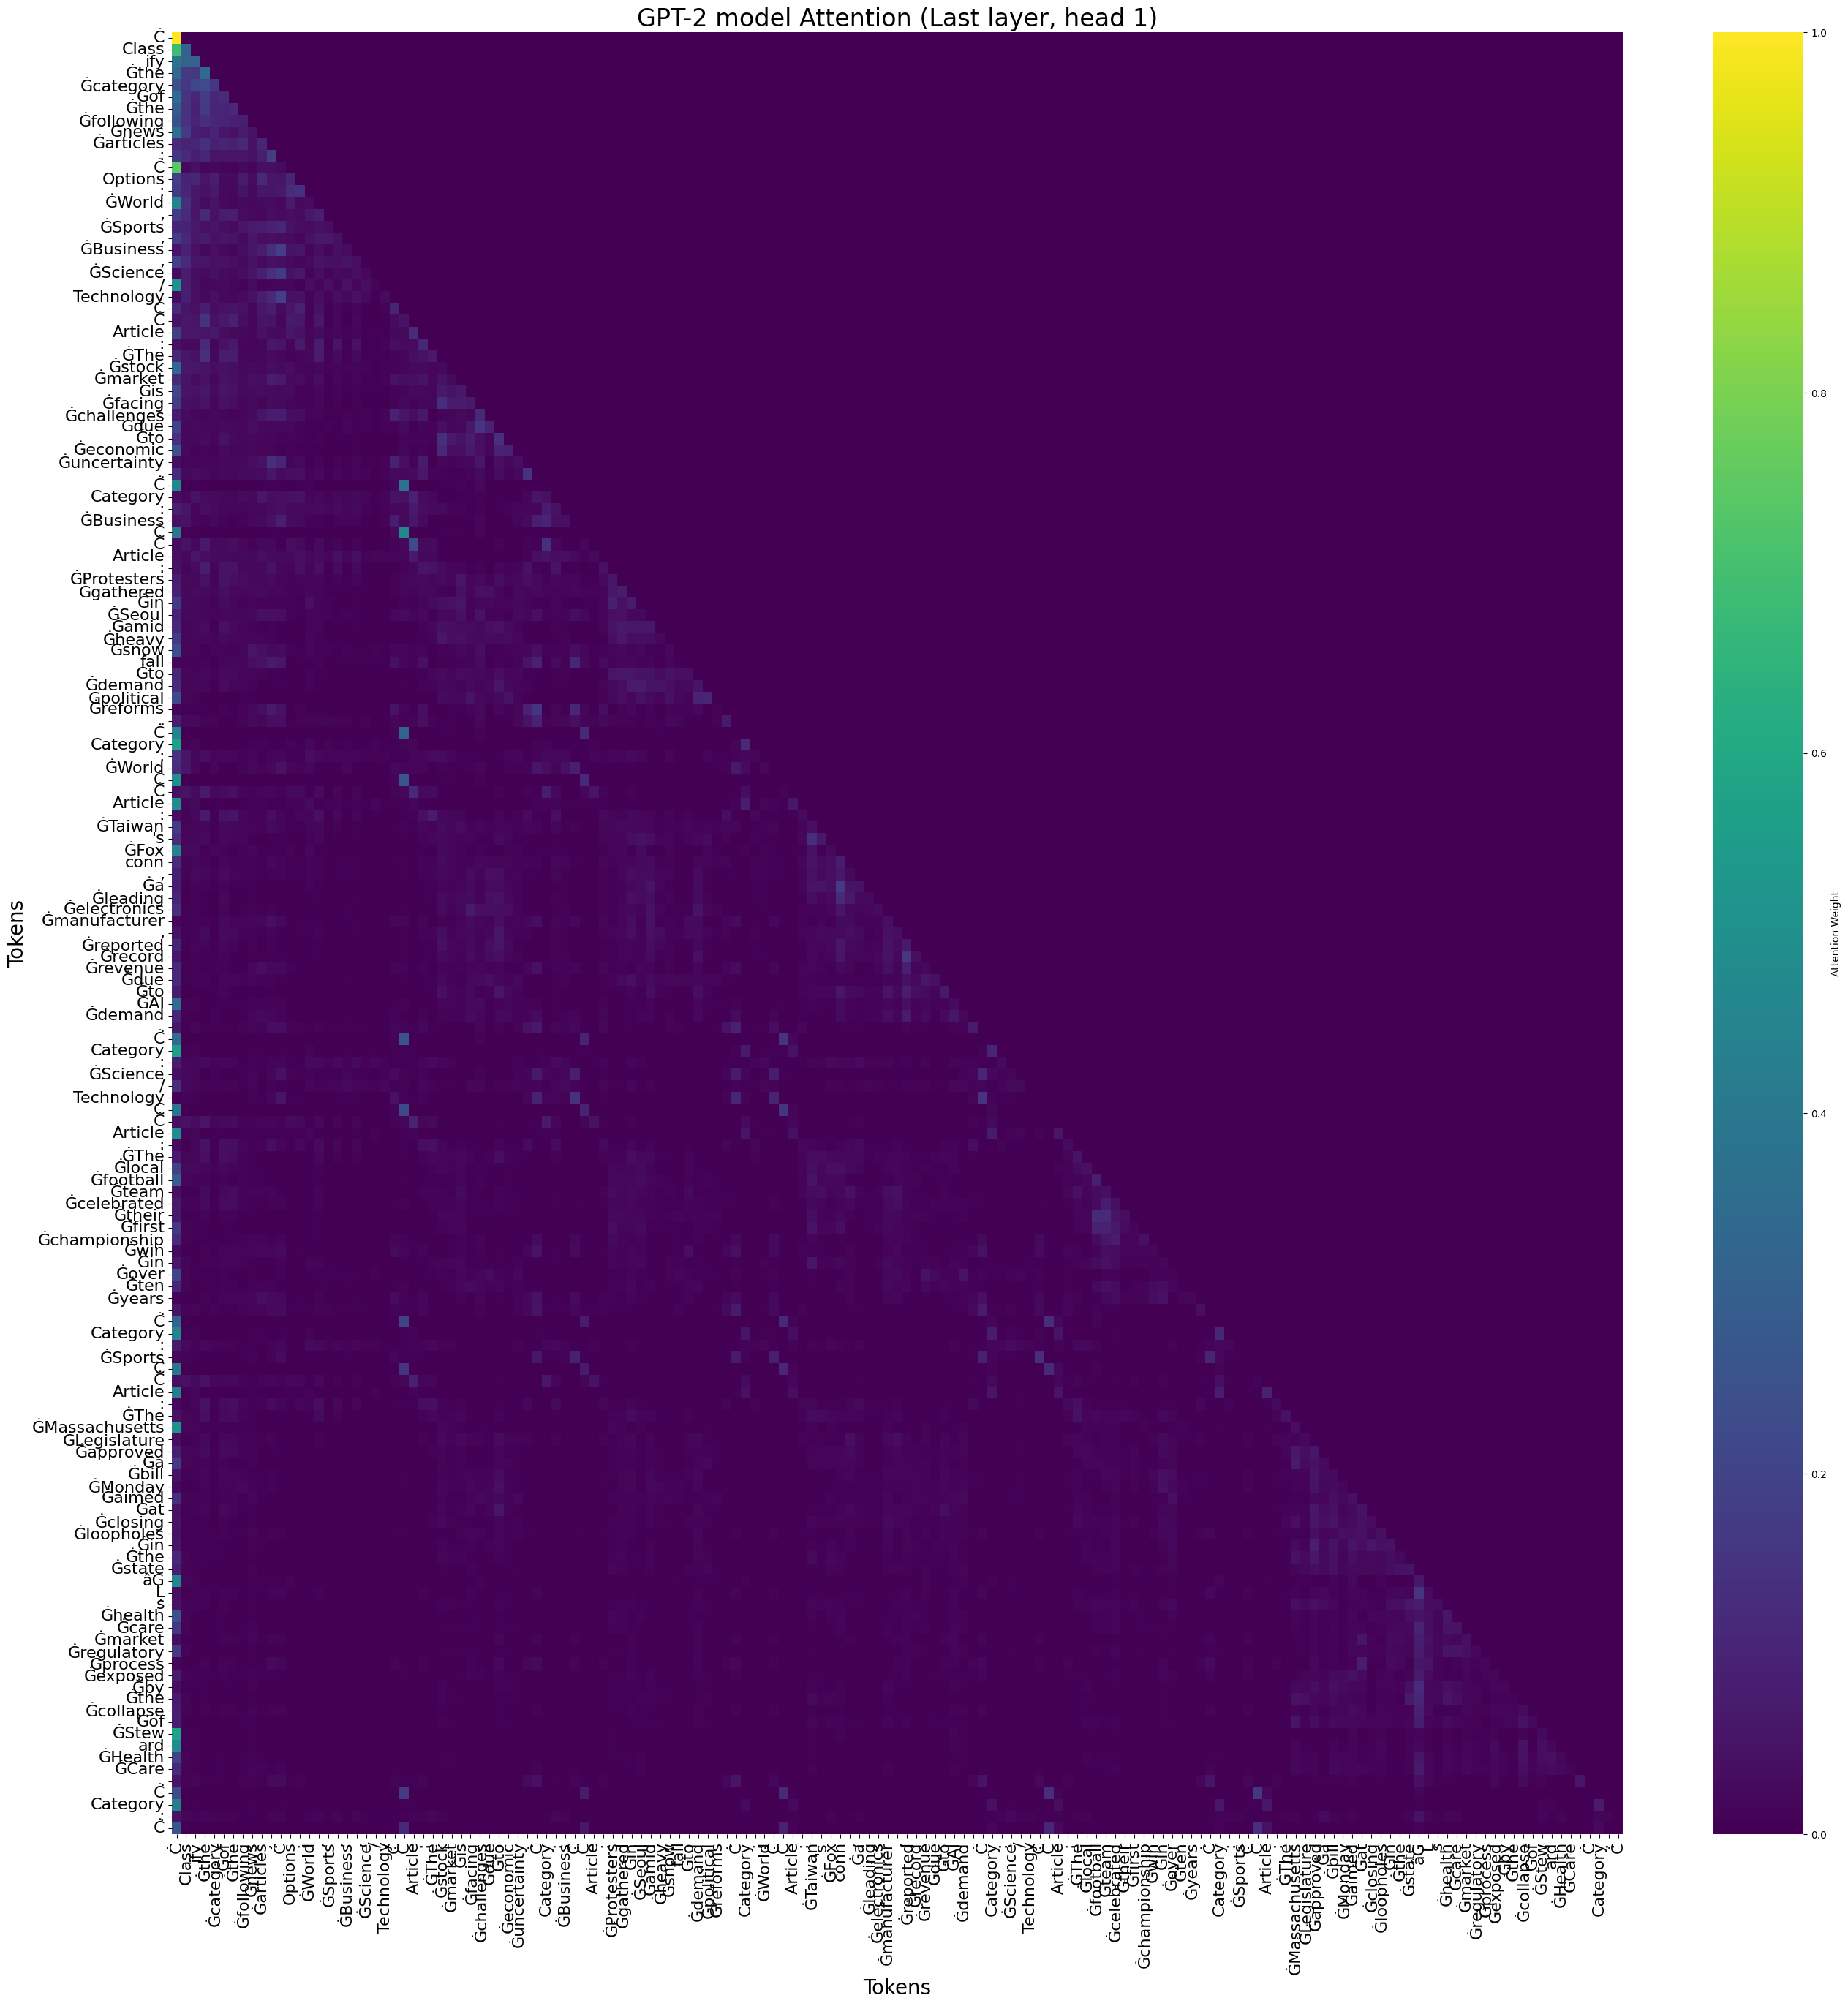

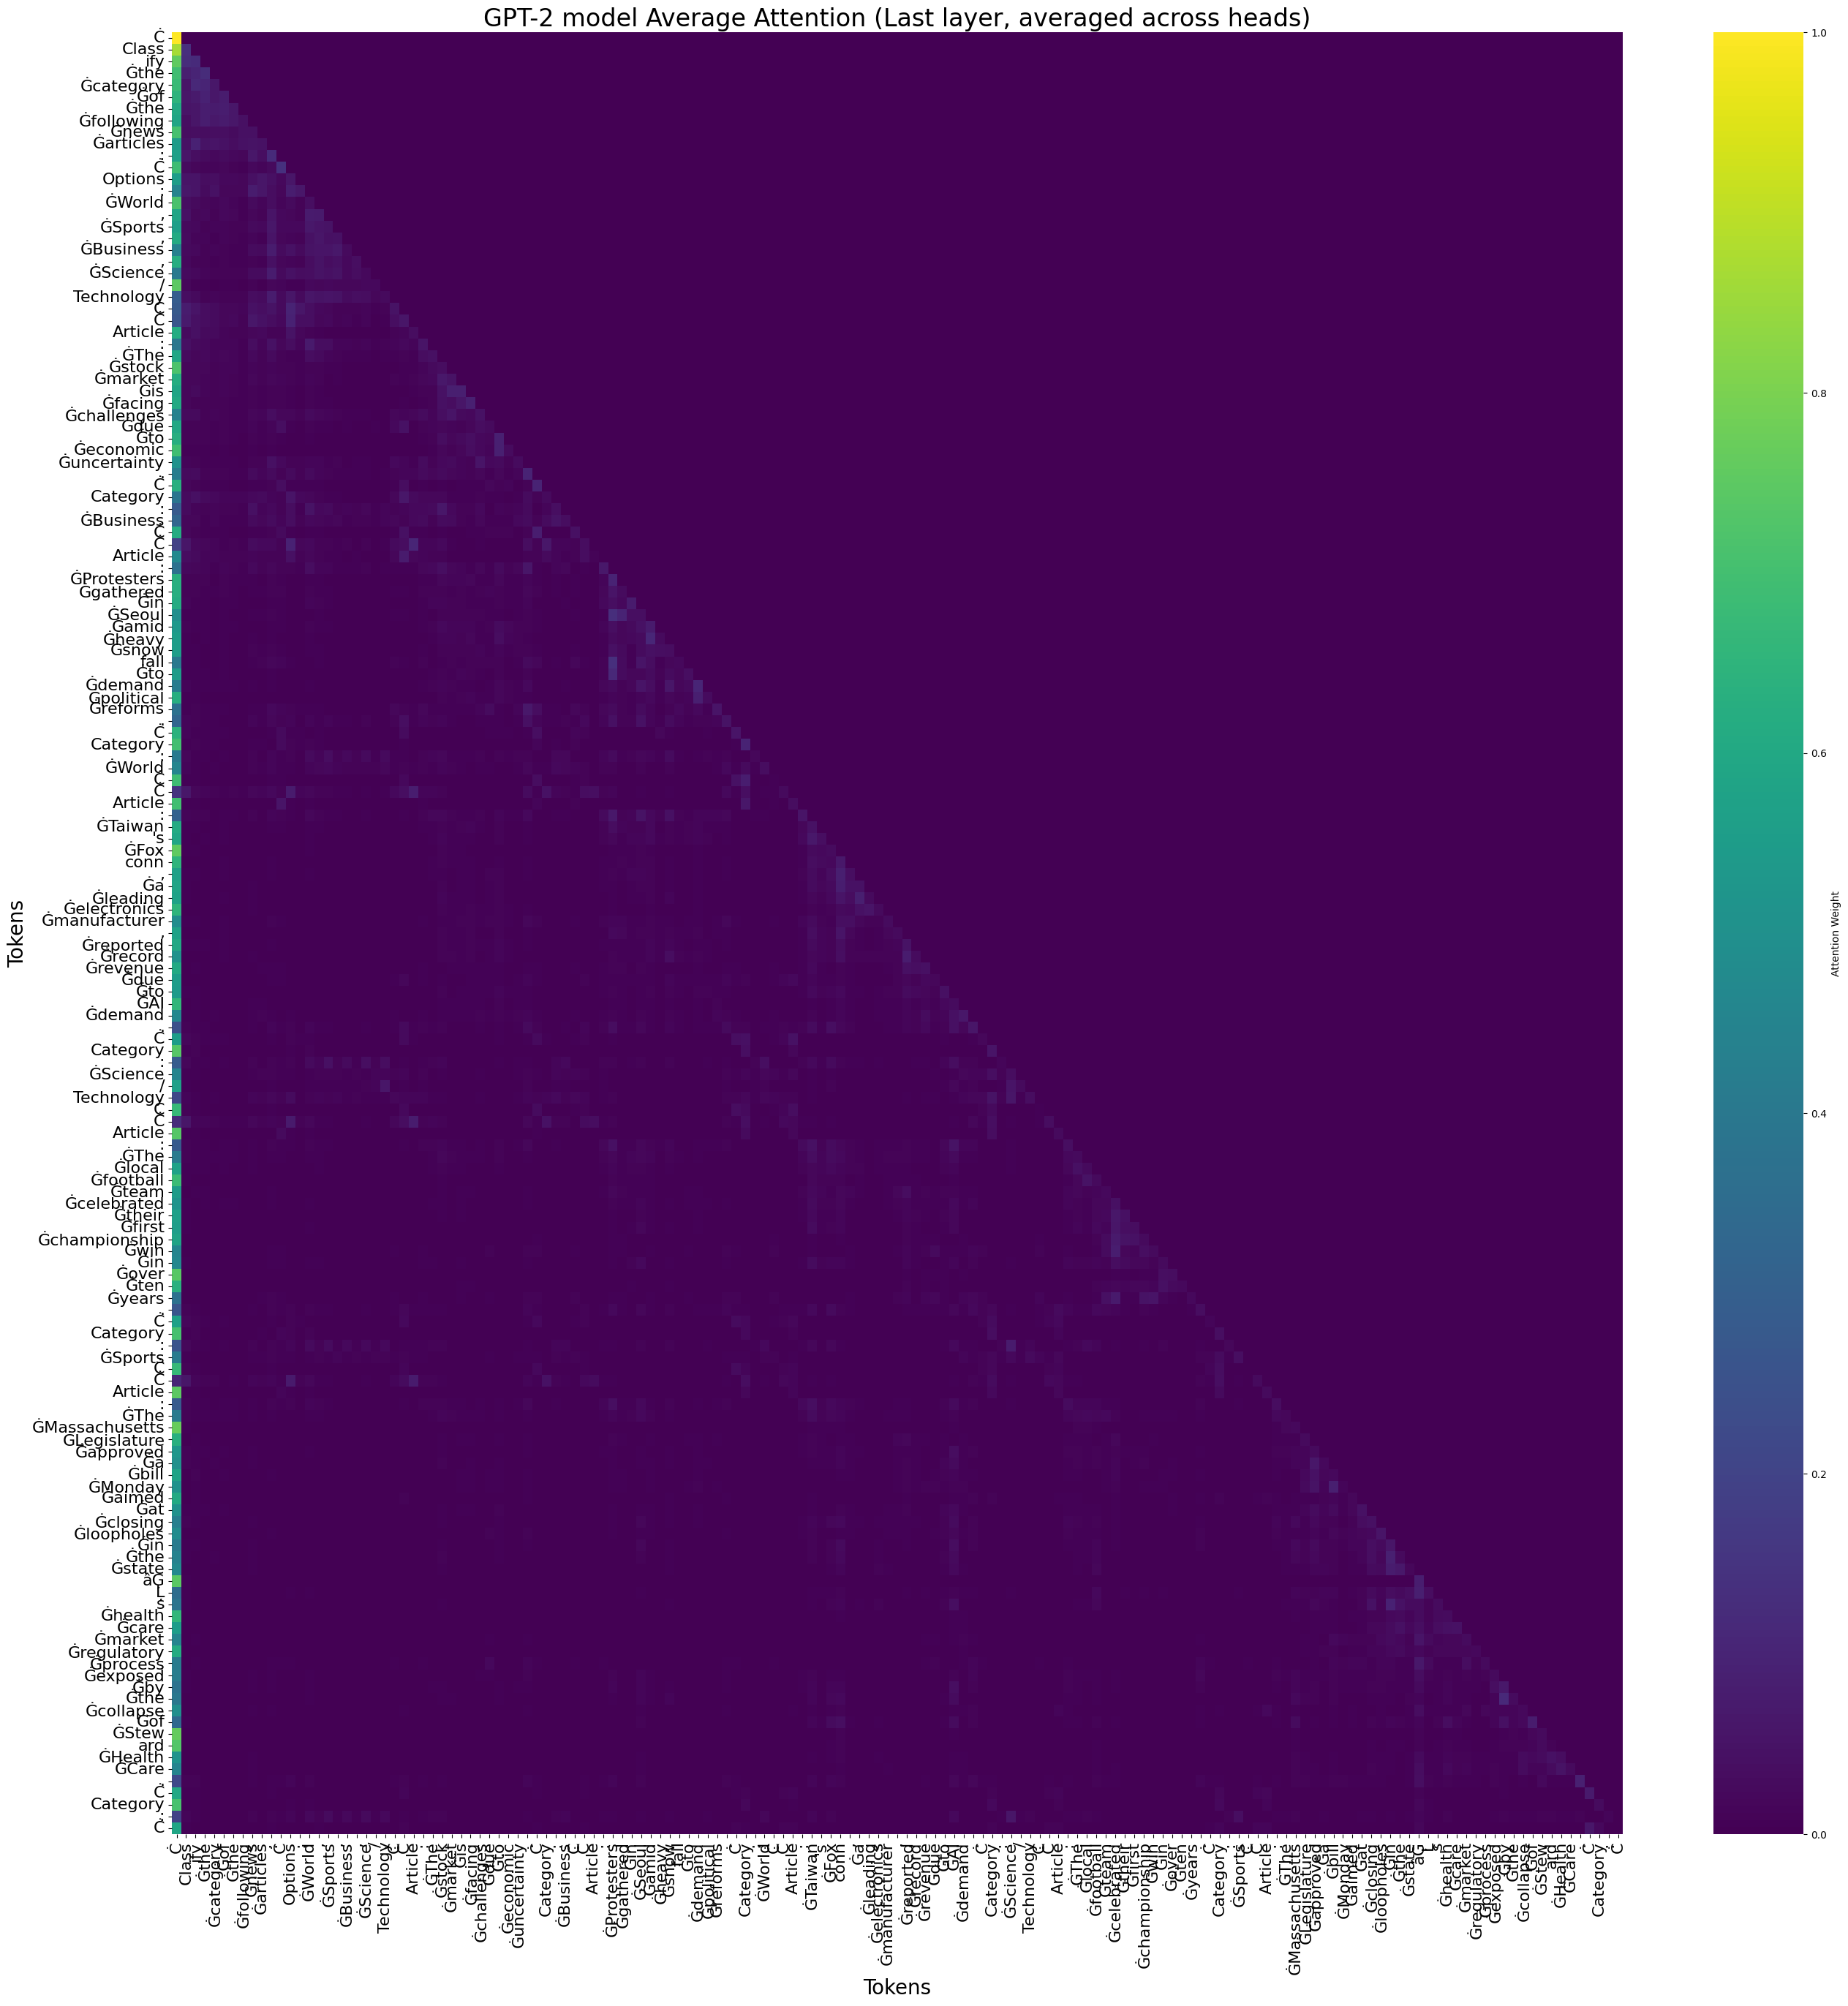

In [136]:
# Get tokens
tokens = tokenizer.convert_ids_to_tokens(inputs[0].tolist())

# Get the attention map for the last layers
attention_map_last_layer = attentions[0][-1] 

# Compute the average attention map across all heads for the last layer
avg_attention_map_last_layer = attention_map_last_layer.mean(dim=1).detach().cpu().numpy()

# Print the average attention map
print("Average attention map (Last layer):")
print(avg_attention_map_last_layer)

# Visualize attention weights for the first attention head of the last layer
attention_map_first_head = attention_map_last_layer[0][0].detach().cpu().numpy()  # Get the attention map for the first head of the last layer

plt.figure(figsize=(32, 32))
sns.heatmap(attention_map_first_head, cmap="viridis", xticklabels=tokens, yticklabels=tokens, cbar_kws={'label': 'Attention Weight'}, annot_kws={"size": 16})
plt.title("GPT-2 model Attention (Last layer, head 1)", fontsize=24)
plt.xlabel("Tokens", fontsize=20)
plt.ylabel("Tokens", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

# Visualize the average attention map of the last layer
plt.figure(figsize=(32, 32))
sns.heatmap(avg_attention_map_last_layer[0], cmap="viridis", xticklabels=tokens, yticklabels=tokens, cbar_kws={'label': 'Attention Weight'}, annot_kws={"size": 16})
plt.title("GPT-2 model Average Attention (Last layer, averaged across heads)", fontsize=24)
plt.xlabel("Tokens", fontsize=20)
plt.ylabel("Tokens", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()